# Homework <a class="anchor" id="section_homework"></a>

**HW 2/1**: <br>
Smart up our plotter to be able to customize the hard-coded layout setup inside the function. Add more custom feature that you would like to use.

**HW 2/2**: <br>
Upgrade the BSM call option pricer to be able to return the greeks as well, not just the price.

**HW 2/3**: <br>
Implement the BSM pricer for European put option.

**HW 2/4**: <br>
With the call and put pricer, check if Put-Call parity holds in practice.

In [12]:
# packages required
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from typing import Dict, List, Union
from scipy.stats import norm

In [13]:
def my_plotter(
    x: List[float],
    y: Union[List[float], List[List[float]]],
    layout: Dict = {},
    names: List[str] = None
) -> None:

    y = [y] if all(isinstance(item, float) for item in y) else y

    plt.figure(figsize=(8, 4))


    show_legend = True if names is not None else False

    plot_kwargs = {
        'linestyle': 'solid',
        'linewidth': 4
    }

    if names is not None:
        show_legend = True

        if len(names) != len(y):
            raise ValueError(
                "Length of names is not matching with number of plotted y lists."
            )

    for i, y_item in enumerate(y):

        if show_legend:
            plot_kwargs['label'] = names[i]

        _line = plt.plot(x, y_item, **plot_kwargs)
        lines.append(_line)

    if show_legend:
        plt.legend(fontsize=16)

    if 'title' in layout:
        plt.title(layout['title'], fontsize=20)
        rcParams['axes.titlepad'] = 30

    if 'x_label' in layout:
        plt.xlabel(layout['x_label'], fontsize=16)
        rcParams['axes.labelpad'] = 20

    ax = plt.gca()
    ax.axhline(linestyle='--', color='black', linewidth=1)

    plt.show()

**HW 2/1**: <br>
Smart up our plotter to be able to customize the hard-coded layout setup inside the function. Add more custom feature that you would like to use.


In [14]:
def my_plotter(
    x: List[float],
    y: Union[List[float], List[List[float]]],
    layout: Dict = {},
    names: List[str] = None
) -> None:

    y = [y] if all(isinstance(item, float) for item in y) else y

    plt.figure(figsize=layout.get('figsize', (8, 4)))

    show_legend = names is not None

    colors = layout.get('colors',['purple', 'blue', 'green', 'red', 'orange', 'skyblue', 'chartreuse'])
    styles = layout.get('styles', ['solid', 'dashed', 'dotted', 'dashdot'])

    if names is not None:
        if len(names) != len(y):
            raise ValueError(
                "Length of names is not matching with number of plotted y lists."
            )

    for i, y_item in enumerate(y):

        plot_kwargs = {
            'linestyle': styles[i % len(styles)],
            'linewidth': layout.get('linewidth', 3),
            'color': colors[i % len(colors)]
        }

        if show_legend:
            plot_kwargs['label'] = names[i]

        plt.plot(x, y_item, **plot_kwargs)

    if show_legend:
        plt.legend(fontsize=14)

    if 'title' in layout:
        plt.title(layout['title'], fontsize=20)

    if 'x_label' in layout:
        plt.xlabel(layout['x_label'], fontsize=16)

    if 'y_label' in layout:
        plt.ylabel(layout['y_label'], fontsize=16)

    ax = plt.gca()
    ax.axhline(linestyle='--', color='black', linewidth=1)

    plt.show()

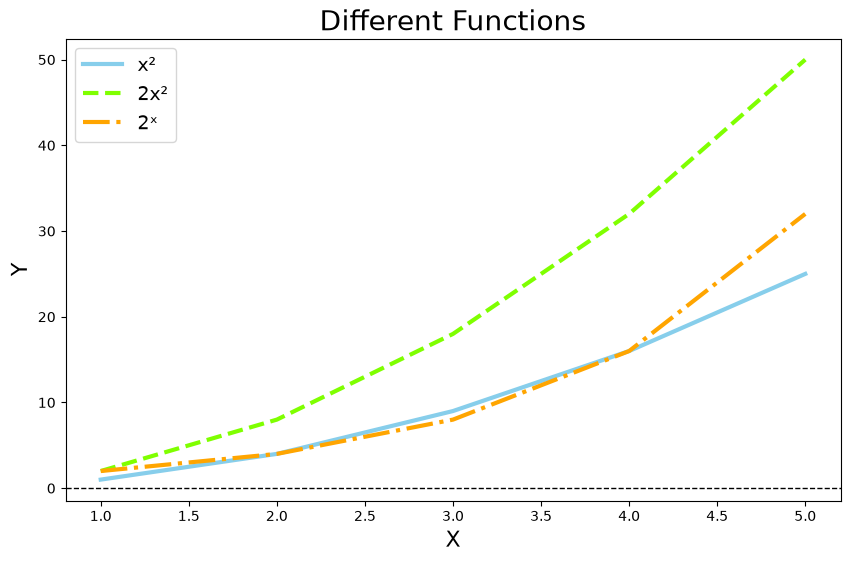

In [15]:
x = [1, 2, 3, 4, 5]

y1 = [x_i**2 for x_i in x]
y2 = [2*x_i**2 for x_i in x]
y3 = [2**x_i for x_i in x]

my_plotter(
    x,
    [y1, y2, y3],
    layout={
        'title': 'Different Functions',
        'x_label': 'X',
        'y_label': 'Y',
        'figsize': (10, 6),
        'linewidth': 3,
        'colors': ['skyblue', 'chartreuse', 'orange'],
        'styles': ['solid', 'dashed', 'dashdot']
    },
    names=['x²', '2x²', '2ˣ']
)

**HW 2/2**: <br>
Upgrade the BSM call option pricer to be able to return the greeks as well, not just the price.

In [16]:
def black_scholes_eur_call(
    r: float,
    T: float,
    S0: float,
    sigma: float,
    K
) -> np.ndarray:

    assert sigma > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = (
        np.log(S0 / K) + (r + 0.5 * sigma**2) * T
    ) / (sigma * T**0.5)

    d2_vec = d1_vec - sigma * T**0.5

    N_d1_vec = norm.cdf(d1_vec)
    N_d2_vec = norm.cdf(d2_vec)

    return {
    'price': N_d1_vec * S0 - K * np.exp(-r * T) * N_d2_vec,
    'delta': N_d1_vec,
    'vega': S0 * norm.pdf(d1_vec) * T**0.5,
    'rho': K * T * np.exp(-r * T) * N_d2_vec,
    'gamma': norm.pdf(d1_vec) / (S0 * sigma * T**0.5),
    'theta': (
        -S0 * norm.pdf(d1_vec) * sigma / (2 * T**0.5)
        - r * K * np.exp(-r * T) * N_d2_vec
    )
}
result = black_scholes_eur_call(
    r=0.05,
    T=1.0,
    S0=20.0,
    sigma=0.3,
    K=20.0
)

print(result)


{'price': array([2.84625096]), 'delta': array([0.62425173]), 'vega': array([7.58865866]), 'rho': array([9.6387836]), 'gamma': array([0.06323882]), 'theta': array([-1.62023798])}


**HW 2/3**: <br>
Implement the BSM pricer for European put option.

In [17]:
def black_scholes_eur_put(
    r: float,
    T: float,
    S0: float,
    sigma: float,
    K
) -> np.ndarray:

    assert sigma > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = (
        np.log(S0 / K) + (r + 0.5 * sigma**2) * T
    ) / (sigma * T**0.5)

    d2_vec = d1_vec - sigma * T**0.5

    N_minus_d1_vec = norm.cdf(-d1_vec)
    N_minus_d2_vec = norm.cdf(-d2_vec)

    return K * np.exp(-r * T) * N_minus_d2_vec - S0 * N_minus_d1_vec

In [18]:
put_price = black_scholes_eur_put(
    r=0.05,
    T=1.0,
    S0=20.0,
    sigma=0.3,
    K=20.0
)

print(put_price)

[1.87083945]


**HW 2/4**: <br>
With the call and put pricer, check if Put-Call parity holds in practice.

In [19]:
r = 0.05
T = 1.0
S0 = 20.0
sigma = 0.3
K = 20.0

call_result = black_scholes_eur_call(
    r=r,
    T=T,
    S0=S0,
    sigma=sigma,
    K=K
)

put_price = black_scholes_eur_put(
    r=r,
    T=T,
    S0=S0,
    sigma=sigma,
    K=K
)

call_price = call_result['price']

left_side = call_price - put_price
right_side = S0 - K * np.exp(-r * T)

print("Call price:", call_price)
print("Put price:", put_price)
print("c - p:", left_side)
print("S0 - K exp(-rT):", right_side)

Call price: [2.84625096]
Put price: [1.87083945]
c - p: [0.97541151]
S0 - K exp(-rT): 0.9754115099857188
